In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



Lets load the file into our program

In [2]:
data = pd.read_csv('life_expectancy_data.csv')

Lets display a short part of the data to see how it looks

In [3]:
data.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


Lets calculate how many null values are present in the data set 

In [4]:
data.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                      8
Adult Mortality                      8
infant deaths                        0
Alcohol                            185
percentage expenditure               0
Hepatitis B                        525
Measles                              0
 BMI                                33
under-five deaths                    0
Polio                               18
Total expenditure                  215
Diphtheria                          18
 HIV/AIDS                            0
GDP                                415
Population                         604
 thinness  1-19 years               33
 thinness 5-9 years                 33
Income composition of resources    155
Schooling                          151
dtype: int64

Here we can quickly analyze the data by looking at the maximum minimum and mean values

In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2732.0,2.007501e+03,4.626314e+00,2000.00000,2003.000000,2.007000e+03,2.012000e+03,2.015000e+03
Life expectancy,2724.0,6.912023e+01,9.511317e+00,36.30000,63.000000,7.200000e+01,7.560000e+01,8.900000e+01
Adult Mortality,2724.0,1.659236e+02,1.238376e+02,1.00000,75.000000,1.450000e+02,2.282500e+02,7.230000e+02
infant deaths,2732.0,3.058895e+01,1.181583e+02,0.00000,0.000000,3.000000e+00,2.300000e+01,1.800000e+03
Alcohol,2547.0,4.555748e+00,4.034548e+00,0.01000,0.850000,3.650000e+00,7.600000e+00,1.787000e+01
percentage expenditure,2732.0,7.270496e+02,1.974304e+03,0.00000,4.595646,6.439528e+01,4.370867e+02,1.947991e+04
Hepatitis B,2207.0,8.086090e+01,2.513078e+01,1.00000,77.000000,9.200000e+01,9.700000e+01,9.900000e+01
Measles,2732.0,2.430581e+03,1.124064e+04,0.00000,0.000000,1.700000e+01,3.705000e+02,2.121830e+05
BMI,2699.0,3.806977e+01,2.006231e+01,1.00000,19.100000,4.290000e+01,5.610000e+01,8.730000e+01
under-five deaths,2732.0,4.238507e+01,1.604804e+02,0.00000,0.000000,4.000000e+00,3.000000e+01,2.500000e+03


In [6]:
list(data.columns)

['Country',
 'Year',
 'Status',
 'Life expectancy ',
 'Adult Mortality',
 'infant deaths',
 'Alcohol',
 'percentage expenditure',
 'Hepatitis B',
 'Measles ',
 ' BMI ',
 'under-five deaths ',
 'Polio',
 'Total expenditure',
 'Diphtheria ',
 ' HIV/AIDS',
 'GDP',
 'Population',
 ' thinness  1-19 years',
 ' thinness 5-9 years',
 'Income composition of resources',
 'Schooling']

If you notice there is empty space before and after some of the columns

This step is to remove the empty space before the names of the columns

In [7]:
data.columns = data.columns.str.strip()

list(data.columns)

['Country',
 'Year',
 'Status',
 'Life expectancy',
 'Adult Mortality',
 'infant deaths',
 'Alcohol',
 'percentage expenditure',
 'Hepatitis B',
 'Measles',
 'BMI',
 'under-five deaths',
 'Polio',
 'Total expenditure',
 'Diphtheria',
 'HIV/AIDS',
 'GDP',
 'Population',
 'thinness  1-19 years',
 'thinness 5-9 years',
 'Income composition of resources',
 'Schooling']

In [8]:
counte = data.groupby("Country")["Population"].count()

counte

Country
Afghanistan                           15
Albania                               15
Algeria                               15
Angola                                16
Antigua and Barbuda                    0
                                      ..
Venezuela (Bolivarian Republic of)     0
Viet Nam                               0
Yemen                                  0
Zambia                                16
Zimbabwe                              14
Name: Population, Length: 191, dtype: int64

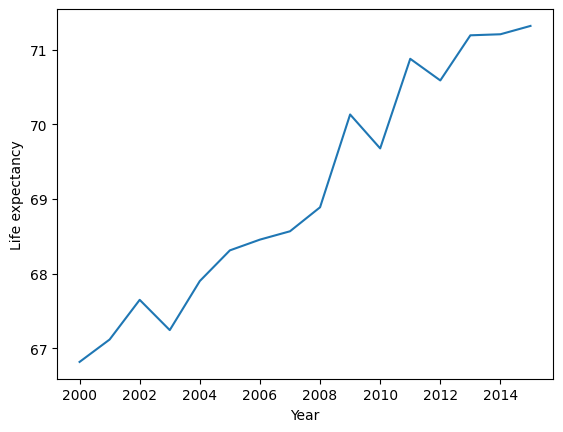

In [9]:
mean_life_expectance = data.groupby("Year")["Life expectancy"].mean()
sns.lineplot(data=mean_life_expectance)
plt.show()

We can see how the population gradually increased as time went on.

In [10]:
# Group by "Country" and check for completely null columns
all_null_columns = data.groupby("Country").apply(lambda x: x.isnull().all())

empty_columns = {
        Country: list(all_null_columns.columns[all_null_columns.loc[Country]])
        for Country in all_null_columns.index
        if all_null_columns.loc[Country].any()
    }

empty_columns_data = pd.DataFrame(list(empty_columns.items()), columns=["Country", "empty_columns"])

# Display result
empty_columns_data

,Country,empty_columns
0,Antigua and Barbuda,[Population]
1,Bahamas,"[GDP, Population]"
2,Bahrain,[Population]
3,Barbados,[Population]
4,Bolivia (Plurinational State of),"[GDP, Population]"
5,Brunei Darussalam,[Population]
6,Congo,"[GDP, Population]"
7,Cuba,[Population]
8,Czechia,"[GDP, Population, Income composition of resour..."
9,Côte d'Ivoire,"[GDP, Population, Income composition of resour..."


It is important to group the countries into larger groups to analyze trends easier.

In [11]:
# Expanding the country-to-region mapping
expanded_country_to_region = {
    # Africa
    'Algeria': 'Africa', 'Angola': 'Africa', 'Benin': 'Africa', 'Botswana': 'Africa',
    'Burkina Faso': 'Africa', 'Burundi': 'Africa', "Côte d'Ivoire": 'Africa',
    'Cabo Verde': 'Africa', 'Cameroon': 'Africa', 'Central African Republic': 'Africa',
    'Chad': 'Africa', 'Comoros': 'Africa', 'Congo': 'Africa',
    'Democratic Republic of the Congo': 'Africa', 'Djibouti': 'Africa', 'Egypt': 'Africa',
    'Equatorial Guinea': 'Africa', 'Eritrea': 'Africa', 'Eswatini': 'Africa',
    'Ethiopia': 'Africa', 'Gabon': 'Africa', 'Gambia': 'Africa', 'Ghana': 'Africa',
    'Guinea': 'Africa', 'Guinea-Bissau': 'Africa', 'Kenya': 'Africa', 'Lesotho': 'Africa',
    'Liberia': 'Africa', 'Libya': 'Africa', 'Madagascar': 'Africa', 'Malawi': 'Africa',
    'Mali': 'Africa', 'Mauritania': 'Africa', 'Mauritius': 'Africa', 'Morocco': 'Africa',
    'Mozambique': 'Africa', 'Namibia': 'Africa', 'Niger': 'Africa', 'Nigeria': 'Africa',
    'Rwanda': 'Africa', 'Sao Tome and Principe': 'Africa', 'Senegal': 'Africa',
    'Seychelles': 'Africa', 'Sierra Leone': 'Africa', 'Somalia': 'Africa',
    'South Africa': 'Africa', 'South Sudan': 'Africa','Swaziland': 'Africa', 'Sudan': 'Africa',
    'Togo': 'Africa','Tunisia' : 'Africa', 'Uganda': 'Africa', 'United Republic of Tanzania': 'Africa',
    'Zambia': 'Africa', 'Zimbabwe': 'Africa',

    # Asia
    'Afghanistan': 'Asia', 'Armenia': 'Asia', 'Azerbaijan': 'Asia', 'Bahrain': 'Asia',
    'Bangladesh': 'Asia', 'Bhutan': 'Asia', 'Brunei Darussalam': 'Asia', 'Cambodia': 'Asia',
    'China': 'Asia', 'Cyprus': 'Asia', "Democratic People's Republic of Korea": 'Asia',
    'Georgia': 'Asia', 'India': 'Asia', 'Indonesia': 'Asia',
    'Iran (Islamic Republic of)': 'Asia', 'Iraq': 'Asia', 'Israel': 'Asia', 'Japan': 'Asia',
    'Jordan': 'Asia', 'Kazakhstan': 'Asia', 'Kuwait': 'Asia', 'Kyrgyzstan': 'Asia',
    "Lao People's Democratic Republic": 'Asia', 'Lebanon': 'Asia', 'Malaysia': 'Asia',
    'Maldives': 'Asia', 'Mongolia': 'Asia', 'Myanmar': 'Asia', 'Nepal': 'Asia',
    'Oman': 'Asia', 'Pakistan': 'Asia', 'Palestine': 'Asia', 'Philippines': 'Asia',
    'Qatar': 'Asia', 'Republic of Korea': 'Asia', 'Saudi Arabia': 'Asia', 'Singapore': 'Asia',
    'Sri Lanka': 'Asia', 'Syrian Arab Republic': 'Asia', 'Tajikistan': 'Asia',
    'Thailand': 'Asia', 'Timor-Leste': 'Asia','The former Yugoslav republic of Macedonia': 'Asia', 'Turkmenistan': 'Asia',
    'United Arab Emirates': 'Asia', 'Uzbekistan': 'Asia', 'Viet Nam': 'Asia',
    'Yemen': 'Asia',

    # Europe
    'Albania': 'Europe', 'Austria': 'Europe', 'Belarus': 'Europe', 'Belgium': 'Europe',
    'Bosnia and Herzegovina': 'Europe', 'Bulgaria': 'Europe', 'Croatia': 'Europe',
    'Czechia': 'Europe', 'Denmark': 'Europe', 'Estonia': 'Europe', 'Finland': 'Europe',
    'France': 'Europe', 'Germany': 'Europe', 'Greece': 'Europe', 'Hungary': 'Europe',
    'Iceland': 'Europe', 'Ireland': 'Europe', 'Italy': 'Europe', 'Latvia': 'Europe',
    'Lithuania': 'Europe', 'Luxembourg': 'Europe', 'Malta': 'Europe', 'Monaco': 'Europe',
    'Montenegro': 'Europe', 'Netherlands': 'Europe', 'North Macedonia': 'Europe',
    'Norway': 'Europe', 'Poland': 'Europe', 'Portugal': 'Europe', 'Republic of Moldova': 'Europe',
    'Romania': 'Europe', 'Russian Federation': 'Europe', 'San Marino': 'Europe',
    'Serbia': 'Europe', 'Slovakia': 'Europe', 'Slovenia': 'Europe', 'Spain': 'Europe',
    'Sweden': 'Europe', 'Switzerland': 'Europe', 'Turkey' : 'Europe', 'Ukraine' : 'Europe',
    'United Kingdom of Great Britain and Northern Ireland': 'Europe',

    # North America
    'Antigua and Barbuda': 'North America', 'Bahamas': 'North America', 'Barbados': 'North America',
    'Belize': 'North America', 'Canada': 'North America', 'Costa Rica': 'North America',
    'Cuba': 'North America', 'Dominican Republic': 'North America', 'El Salvador': 'North America',
    'Grenada': 'North America', 'Guatemala': 'North America', 'Haiti': 'North America',
    'Honduras': 'North America', 'Jamaica': 'North America', 'Mexico': 'North America',
    'Nicaragua': 'North America', 'Panama': 'North America', 'Saint Kitts and Nevis': 'North America',
    'Saint Lucia': 'North America', 'Saint Vincent and the Grenadines': 'North America',
    'Trinidad and Tobago': 'North America', 'United States of America': 'North America',

    # South America
    'Argentina': 'South America', 'Bolivia (Plurinational State of)': 'South America',
    'Brazil': 'South America', 'Chile': 'South America', 'Colombia': 'South America',
    'Ecuador': 'South America', 'Guyana': 'South America', 'Paraguay': 'South America',
    'Peru': 'South America', 'Suriname': 'South America', 'Uruguay': 'South America',
    'Venezuela (Bolivarian Republic of)': 'South America',

    # Oceania
    'Australia': 'Oceania', 'Fiji': 'Oceania', 'Kiribati': 'Oceania',
    'Marshall Islands': 'Oceania', 'Micronesia (Federated States of)': 'Oceania',
    'Nauru': 'Oceania', 'New Zealand': 'Oceania','Niue' : 'Oceania', 'Palau': 'Oceania',
    'Papua New Guinea': 'Oceania', 'Samoa': 'Oceania', 'Solomon Islands': 'Oceania',
    'Tonga': 'Oceania', 'Tuvalu': 'Oceania', 'Vanuatu': 'Oceania'
}


# Add or update the Region column
data['Region'] = data['Country'].map(expanded_country_to_region)

# # Check for any remaining unmapped countries
# remaining_unmapped = df[df['Region'].isna()]['Country'].unique()
# remaining_unmapped


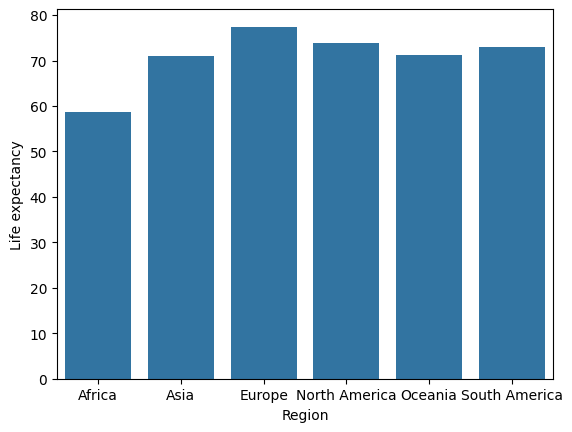

In [12]:
region_life_expectance = data.groupby("Region")["Life expectancy"].mean()
sns.barplot(data=region_life_expectance)
plt.show()

Here we can see the life expectancy among the different groups 

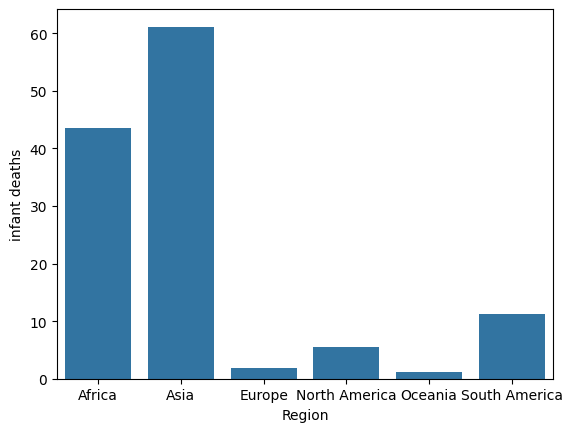

In [13]:
region_infant_deaths = data.groupby("Region")["infant deaths"].mean()
sns.barplot(data=region_infant_deaths)
plt.show()

And here we can see that the infant deaths in Africa and Asia are very high compared to the rest of the world, while the opposite is observed in life expectancy

In [14]:
single_record_countries = data.groupby("Country").filter(lambda x: len(x) == 1)["Country"].unique()
# single_record_countries

data.loc[data['Country'].isin(single_record_countries)]

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Region
1543,Marshall Islands,2013,Developing,NaN,NaN,0,0.01,871.878317,8.0,0,...,17.24,79.0,0.1,3617.752354,NaN,0.1,0.1,NaN,0.0,Oceania
1604,Monaco,2013,Developing,NaN,NaN,0,0.01,0.000000,99.0,0,...,4.30,99.0,0.1,NaN,NaN,NaN,NaN,NaN,NaN,Europe
1693,Nauru,2013,Developing,NaN,NaN,0,0.01,15.606596,87.0,0,...,4.65,87.0,0.1,136.183210,NaN,0.1,0.1,NaN,9.6,Oceania
1783,Niue,2013,Developing,NaN,NaN,0,0.01,0.000000,99.0,0,...,7.20,99.0,0.1,NaN,NaN,0.1,0.1,NaN,NaN,Oceania
1825,Palau,2013,Developing,NaN,NaN,0,NaN,344.690631,99.0,0,...,9.27,99.0,0.1,1932.122370,292.0,0.1,0.1,0.779,14.2,Oceania
2012,Saint Kitts and Nevis,2013,Developing,NaN,NaN,0,8.54,0.000000,97.0,0,...,6.14,96.0,0.1,NaN,NaN,3.7,3.6,0.749,13.4,North America
2053,San Marino,2013,Developing,NaN,NaN,0,0.01,0.000000,69.0,0,...,6.50,69.0,0.1,NaN,NaN,NaN,NaN,NaN,15.1,Europe
2521,Tuvalu,2013,Developing,NaN,NaN,0,0.01,78.281203,9.0,0,...,16.61,9.0,0.1,3542.135890,1819.0,0.2,0.1,NaN,0.0,Oceania


In [15]:
data["Life expectancy"] = data.groupby("Country")["Life expectancy"].transform(lambda x: x.fillna(x.median()))
data["Adult Mortality"] = data.groupby("Country")["Adult Mortality"].transform(lambda x: x.fillna(x.median()))
data["BMI"] = data.groupby("Country")["BMI"].transform(lambda x: x.fillna(x.median()))
data["Alcohol"] = data.groupby("Country")["Alcohol"].transform(lambda x: x.fillna(x.median()))
data["thinness  1-19 years"] = data.groupby("Country")["thinness  1-19 years"].transform(lambda x: x.fillna(x.median()))

c:\Python39\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Python39\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Python39\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Python39\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Python39\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Python39\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Python39\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeW

We are filling in the data in the missing places by calculating the mean values

In [16]:
for col in ["Polio", "Diphtheria", "Hepatitis B"]:
    data[col] = data.groupby("Country")[col].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x))

In [17]:
countries_with_nulls = data[data["Schooling"].isna()]["Country"].unique()

countries_with_nulls

array(["Côte d'Ivoire", 'Czechia',
       "Democratic People's Republic of Korea",
       'Democratic Republic of the Congo', 'Monaco', 'Niue',
       'Republic of Korea', 'Republic of Moldova', 'Somalia',
       'United Kingdom of Great Britain and Northern Ireland',
       'United Republic of Tanzania', 'United States of America'],
      dtype=object)

In [18]:
target_countries = ['Denmark', 'Finland', 'Hungary', 'Iceland', 'Japan', 'Norway',
       'Slovenia', 'Switzerland',
       'United Kingdom of Great Britain and Northern Ireland'] 

region_means = data.groupby("Region")["Hepatitis B"].mean()

for country in target_countries:
    region = data.loc[data["Country"] == country, "Region"].iloc[0]
    mean_value = region_means[region]
    data.loc[(data["Country"] == country) & (data["Hepatitis B"].isna()), "Hepatitis B"] = mean_value

In [19]:
for col in ["GDP", "Population", "Total expenditure", "Schooling"]:
    data[col] = data.groupby("Country")[col].transform(lambda x: x.interpolate(method='linear'))

In [20]:
target_countries_2 = ["Côte d'Ivoire", 'Czechia',
       "Democratic People's Republic of Korea",
       'Democratic Republic of the Congo', 'Monaco', 'Niue',
       'Republic of Korea', 'Republic of Moldova', 'Somalia',
       'United Kingdom of Great Britain and Northern Ireland',
       'United Republic of Tanzania', 'United States of America'] 

region_school_means = data.groupby("Region")["Schooling"].mean()

for countrie in target_countries_2:
    regiona = data.loc[data["Country"] == countrie, "Region"].iloc[0]
    mean_value_2 = region_school_means[regiona]
    data.loc[(data["Country"] == countrie) & (data["Schooling"].isna()), "Schooling"] = mean_value_2

In [21]:
data.drop(['life_expectancy', 'adult_mortality'], axis=1, inplace=True)

KeyError: "['life_expectancy', 'adult_mortality'] not found in axis"

In [ ]:
data.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                      8
Adult Mortality                      8
infant deaths                        0
Alcohol                             17
percentage expenditure               0
Hepatitis B                          0
Measles                              0
BMI                                 33
under-five deaths                    0
Polio                                0
Total expenditure                  201
Diphtheria                           0
HIV/AIDS                             0
GDP                                391
Population                         604
thinness  1-19 years                33
thinness 5-9 years                  33
Income composition of resources    155
Schooling                            0
Region                               0
dtype: int64

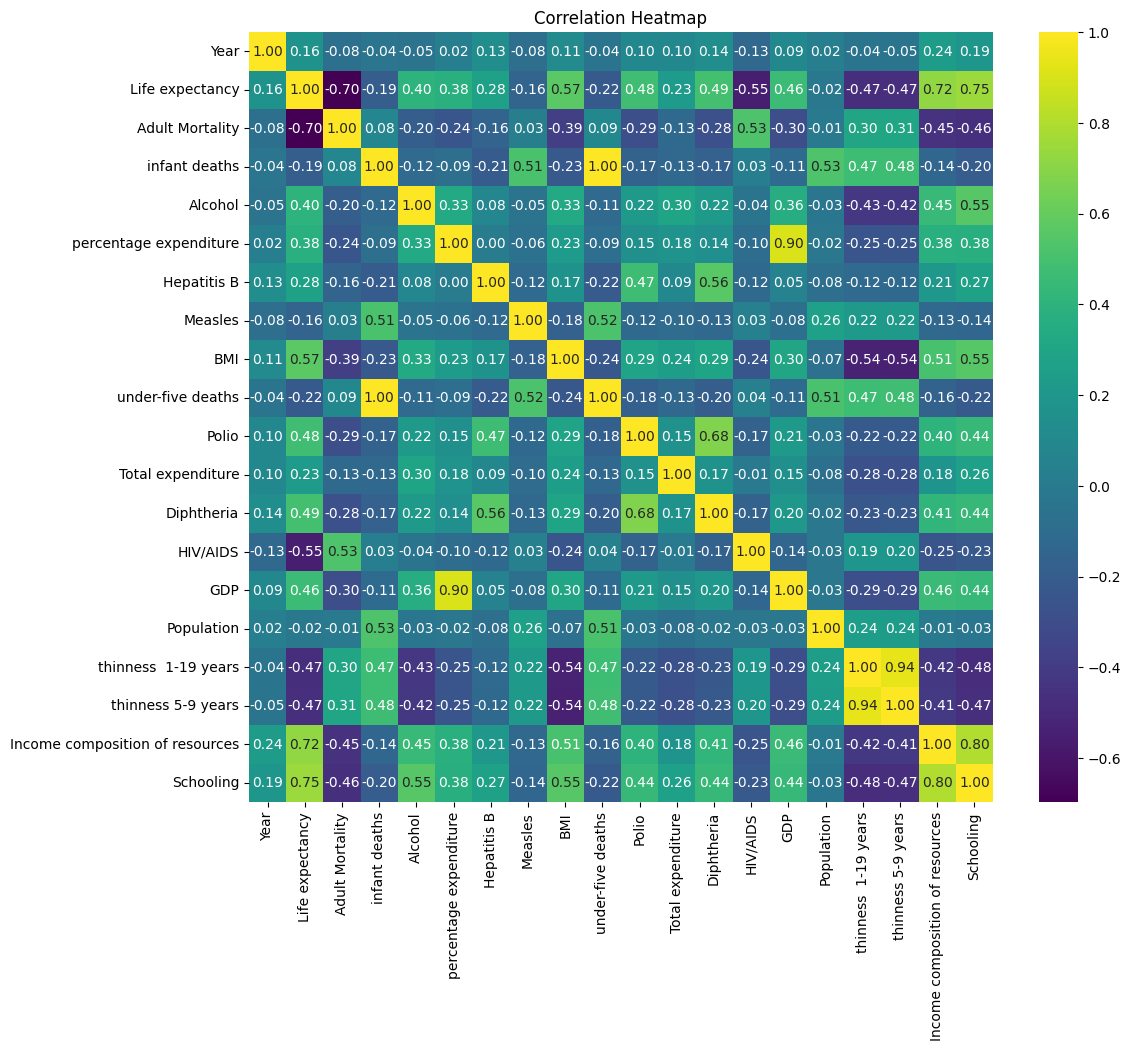

In [ ]:
correlation_matrix = data.corr(numeric_only=True)

# Step 3: Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

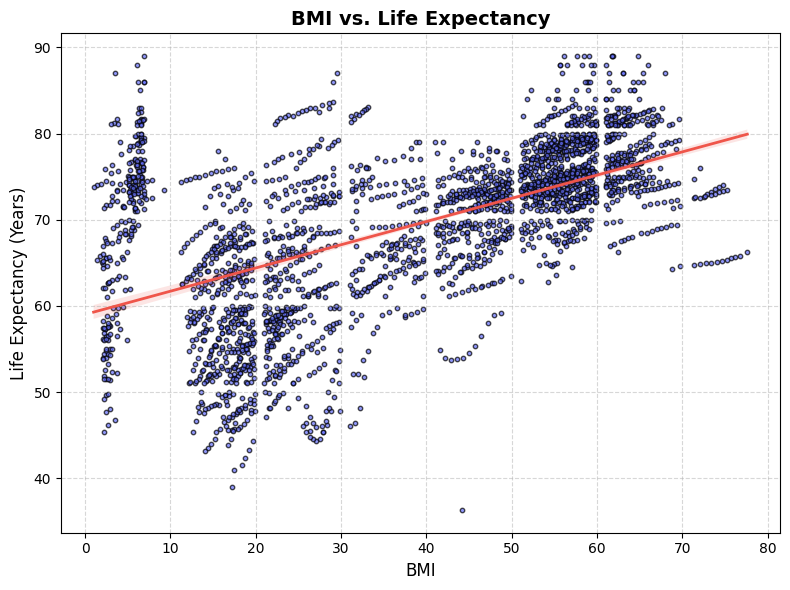

In [ ]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=data,
    x="BMI",
    y="Life expectancy",
    scatter_kws={'s': 10, 'color': '#636EFA', 'alpha': 0.7, 'edgecolor': 'black'},
    line_kws={'color': '#EF554A', 'linewidth': 2},
)

plt.title("BMI vs. Life Expectancy", fontsize=14, weight='bold')
plt.xlabel("BMI", fontsize=12)
plt.ylabel("Life Expectancy (Years)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

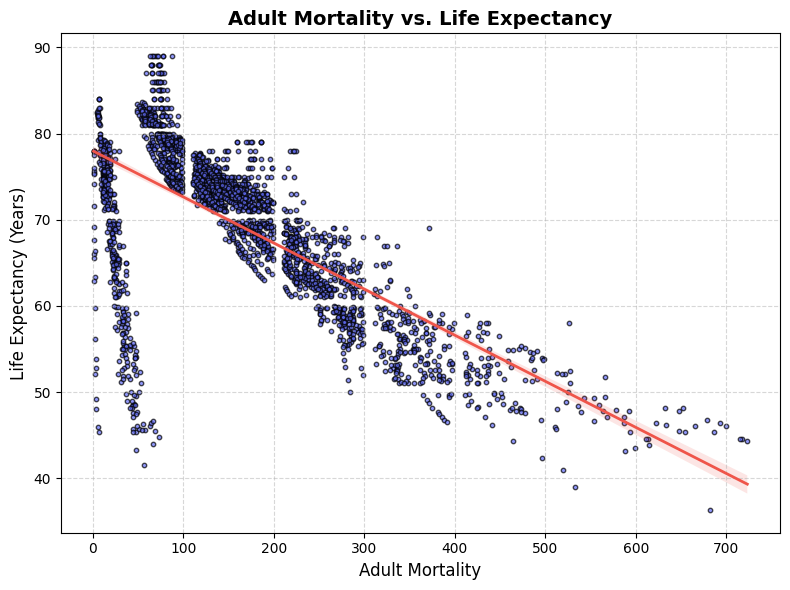

In [ ]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=data,
    x="Adult Mortality",
    y="Life expectancy",
    scatter_kws={'s': 10, 'color': '#636EFA', 'alpha': 0.7, 'edgecolor': 'black'},
    line_kws={'color': '#EF554A', 'linewidth': 2},
)

plt.title("Adult Mortality vs. Life Expectancy", fontsize=14, weight='bold')
plt.xlabel("Adult Mortality", fontsize=12)
plt.ylabel("Life Expectancy (Years)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

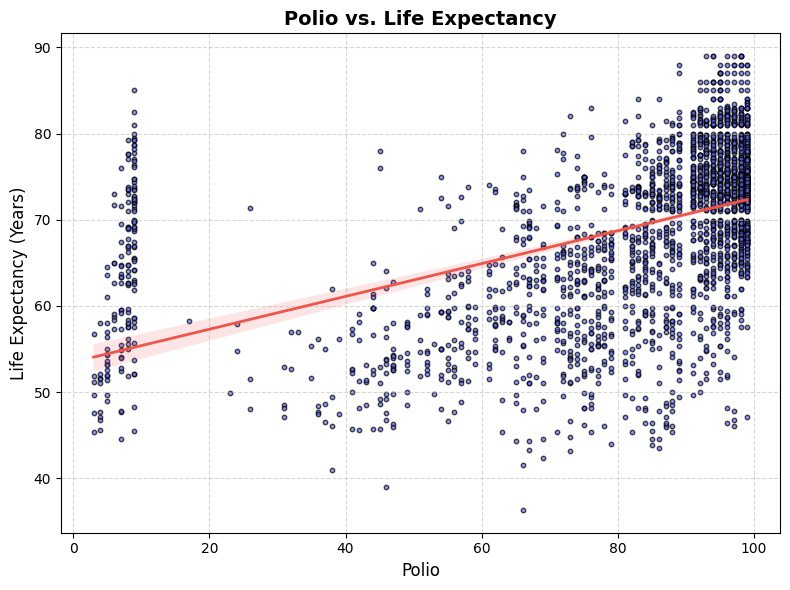

In [ ]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=data,
    x="Polio",
    y="Life expectancy",
    scatter_kws={'s': 10, 'color': '#636EFA', 'alpha': 0.7, 'edgecolor': 'black'},
    line_kws={'color': '#EF554A', 'linewidth': 2},
)

plt.title("Polio vs. Life Expectancy", fontsize=14, weight='bold')
plt.xlabel("Polio", fontsize=12)
plt.ylabel("Life Expectancy (Years)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

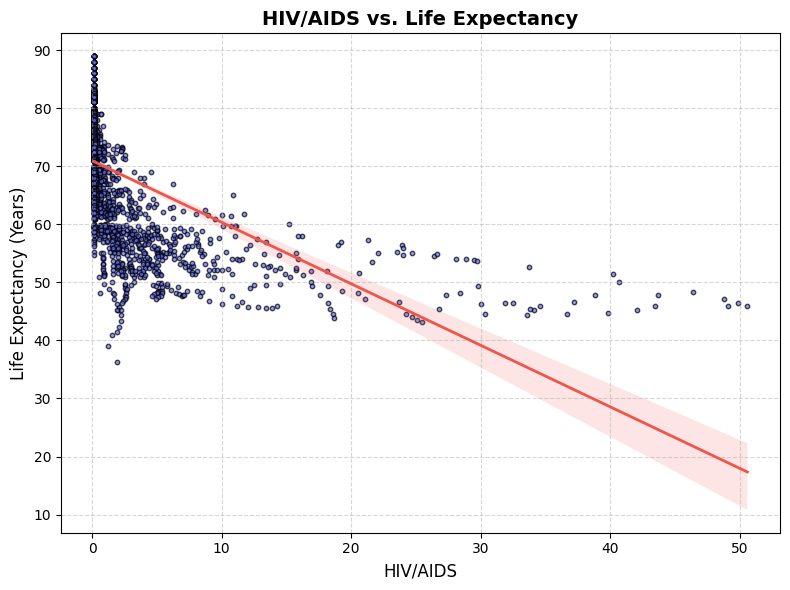

In [ ]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=data,
    x="HIV/AIDS",
    y="Life expectancy",
    scatter_kws={'s': 10, 'color': '#636EFA', 'alpha': 0.7, 'edgecolor': 'black'},
    line_kws={'color': '#EF554A', 'linewidth': 2},
)

plt.title("HIV/AIDS vs. Life Expectancy", fontsize=14, weight='bold')
plt.xlabel("HIV/AIDS", fontsize=12)
plt.ylabel("Life Expectancy (Years)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

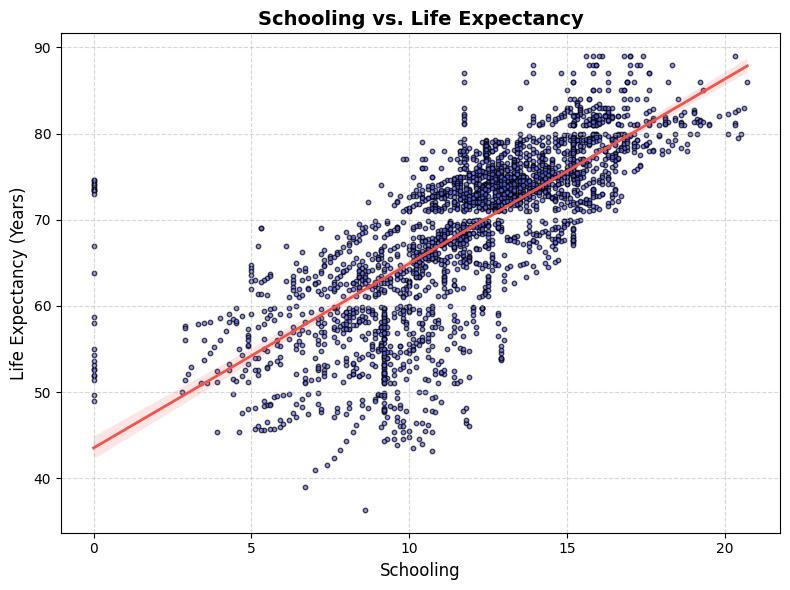

In [ ]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=data,
    x="Schooling",
    y="Life expectancy",
    scatter_kws={'s': 10, 'color': '#636EFA', 'alpha': 0.7, 'edgecolor': 'black'},
    line_kws={'color': '#EF554A', 'linewidth': 2},
)

plt.title("Schooling vs. Life Expectancy", fontsize=14, weight='bold')
plt.xlabel("Schooling", fontsize=12)
plt.ylabel("Life Expectancy (Years)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

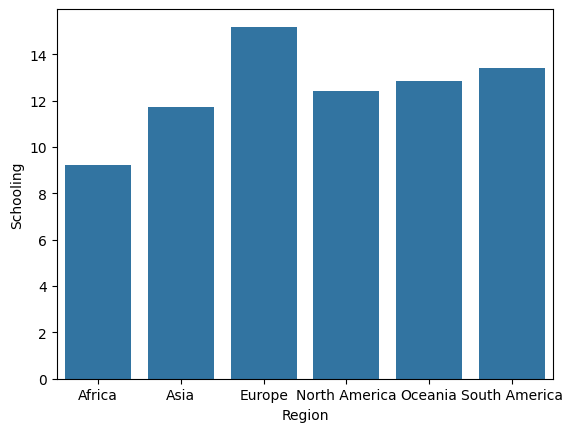

In [ ]:
region_schooling = data.groupby("Region")["Schooling"].mean()
sns.barplot(data=region_schooling)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_10700\813400905.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


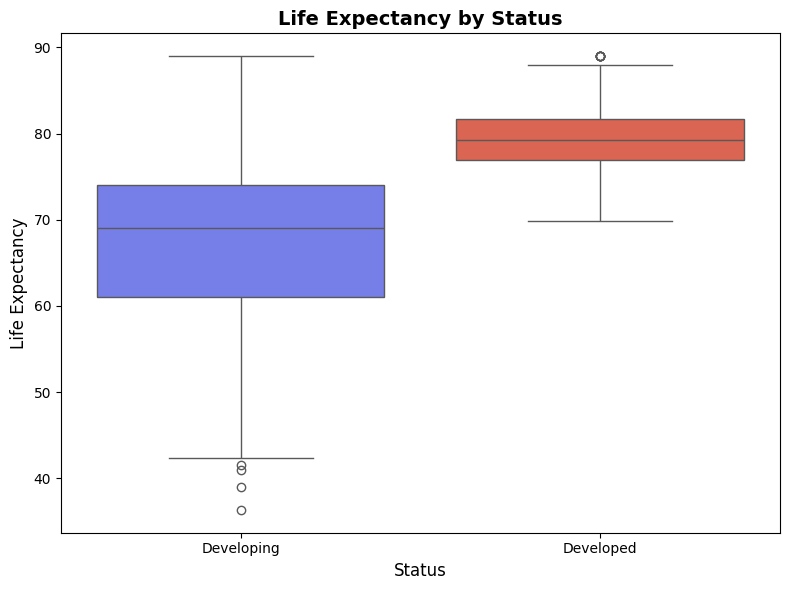

In [ ]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data,
    x="Status",
    y="Life expectancy",
    palette=["#636EFA", "#EF553B"]
)

plt.title("Life Expectancy by Status", fontsize=14, weight='bold')
plt.xlabel("Status", fontsize=12)
plt.ylabel("Life Expectancy", fontsize=12)

plt.tight_layout()
plt.show()

In [22]:
data.to_csv("data/raw/life_expectancy_data.csv", index=False)